<a href="https://colab.research.google.com/github/LeonimerMelo/Recurrent-Networks/blob/LSTM/Time_series_forecasting_with_LSTM_for_uni_multivar_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# https://www.kaggle.com/code/mineshjethva/time-series-forecasting-with-lstm-for-uni-multivar
import tensorflow as tf

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

In [2]:
zip_path = tf.keras.utils.get_file(
    origin='https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip',
    fname='jena_climate_2009_2016.csv.zip',
    extract=True)
csv_path, _ = os.path.splitext(zip_path)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
csv_path

'/root/.keras/datasets/jena_climate_2009_2016_extracted'

In [5]:
path=csv_path+'/jena_climate_2009_2016.csv'

In [7]:
df = pd.read_csv(path)
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420546,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420547,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420548,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8


In [8]:
def univariate_data(dataset, start_index, end_index, history_size, target_size):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i)
    # Reshape data from (history_size,) to (history_size, 1)
    data.append(np.reshape(dataset[indices], (history_size, 1)))
    labels.append(dataset[i+target_size])
  return np.array(data), np.array(labels)

In [9]:
TRAIN_SPLIT = 300000
tf.random.set_seed(13)

In [11]:
uni_data = df['T (degC)']
uni_data.index = df['Date Time']
uni_data

,T (degC)
Date Time,
01.01.2009 00:10:00,-8.02
01.01.2009 00:20:00,-8.41
01.01.2009 00:30:00,-8.51
01.01.2009 00:40:00,-8.31
01.01.2009 00:50:00,-8.27
...,...
31.12.2016 23:20:00,-4.05
31.12.2016 23:30:00,-3.35
31.12.2016 23:40:00,-3.16


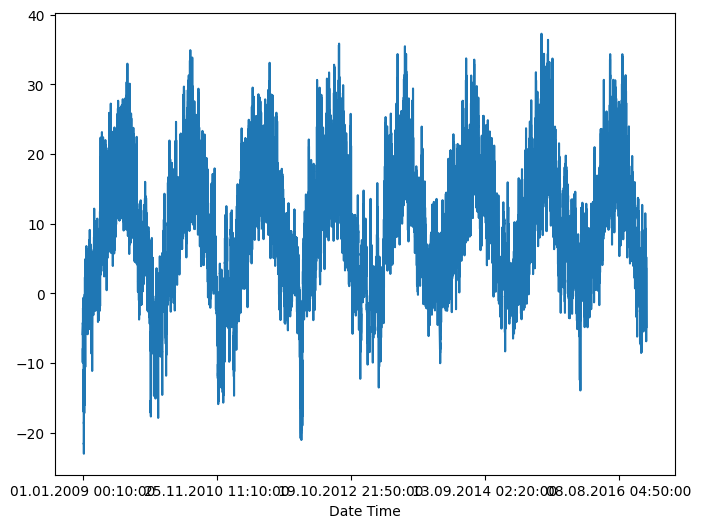

In [15]:
uni_data.plot(subplots=True)
plt.show()

In [16]:
uni_data = uni_data.values
uni_data

array([-8.02, -8.41, -8.51, ..., -3.16, -4.23, -4.82])

In [20]:
uni_train_mean = uni_data[:TRAIN_SPLIT].mean()
uni_train_std = uni_data[:TRAIN_SPLIT].std()

In [21]:
uni_train_mean

np.float64(9.233256299999999)

In [22]:
uni_train_std

np.float64(8.636720398054864)

In [23]:
uni_data = (uni_data-uni_train_mean)/uni_train_std

In [24]:
uni_data

array([-1.99766294, -2.04281897, -2.05439744, ..., -1.43494935,
       -1.55883897, -1.62715193])

In [25]:
uni_data.mean()

np.float64(0.0251126636394392)

In [26]:
uni_data.std()

np.float64(0.9752955760381984)

In [134]:
univariate_past_history = 20
univariate_future_target = 0

x_train_uni, y_train_uni = univariate_data(uni_data, 0, TRAIN_SPLIT,
                                           univariate_past_history,
                                           univariate_future_target)
x_val_uni, y_val_uni = univariate_data(uni_data, TRAIN_SPLIT, None,
                                       univariate_past_history,
                                       univariate_future_target)

In [135]:
print(x_train_uni.shape, y_train_uni.shape)

(299980, 20, 1) (299980,)


In [136]:
print(x_val_uni.shape, y_val_uni.shape)

(120521, 20, 1) (120521,)


In [137]:
print ('Single window of past history')
print (x_train_uni[0].reshape(-1))
print ('\n Target temperature to predict')
print (y_train_uni[0])

Single window of past history
[-1.99766294 -2.04281897 -2.05439744 -2.0312405  -2.02660912 -2.00113649
 -1.95134907 -1.95134907 -1.98492663 -2.04513467 -2.08334362 -2.09723778
 -2.09376424 -2.09144854 -2.07176515 -2.07176515 -2.07639653 -2.08913285
 -2.09260639 -2.10418486]

 Target temperature to predict
-2.1887076840252155


In [40]:
def create_time_steps(length):
  return list(range(-length, 0))

In [54]:
def show_plot(plot_data, delta, title):
  labels = ['History', 'True Future', 'Model Prediction']
  marker = ['.-', 'rx', 'go']
  time_steps = create_time_steps(plot_data[0].shape[0])
  if delta:
    future = delta
  else:
    future = 0

  plt.title(title)
  for i, x in enumerate(plot_data):
    if i:
      plt.plot(future, plot_data[i], marker[i], markersize=10,
               label=labels[i])
    else:
      plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
  plt.legend()
  plt.xlim([time_steps[0], (future+5)*2])
  plt.xlabel('Time-Step')
  plt.show()
  #return plt

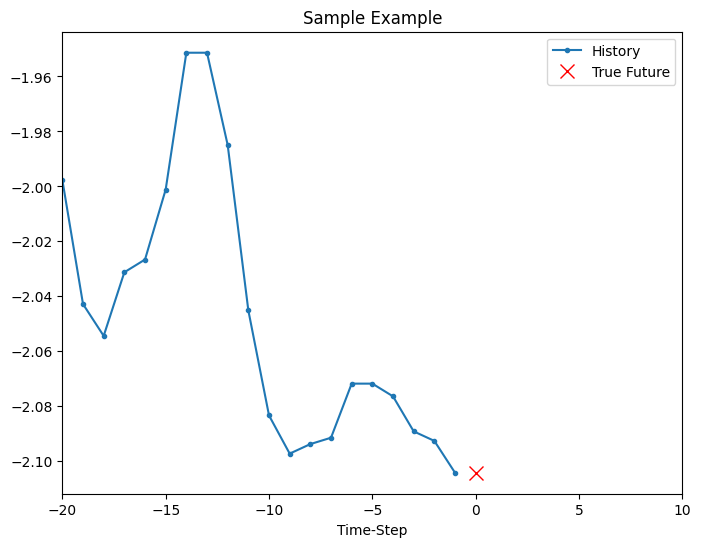

In [55]:
show_plot([x_train_uni[0], y_train_uni[0]], 0, 'Sample Example')

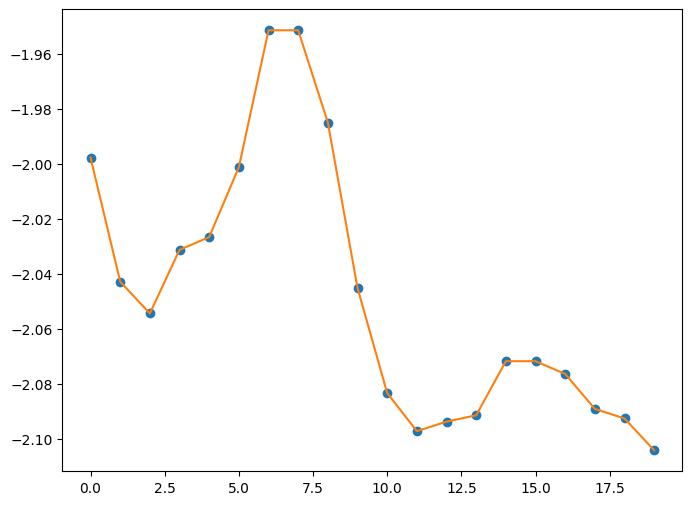

In [51]:
plt.plot(x_train_uni[0],'o')
plt.plot(x_train_uni[0],'-')
plt.show()

In [50]:
def baseline(history):
  return np.mean(history)

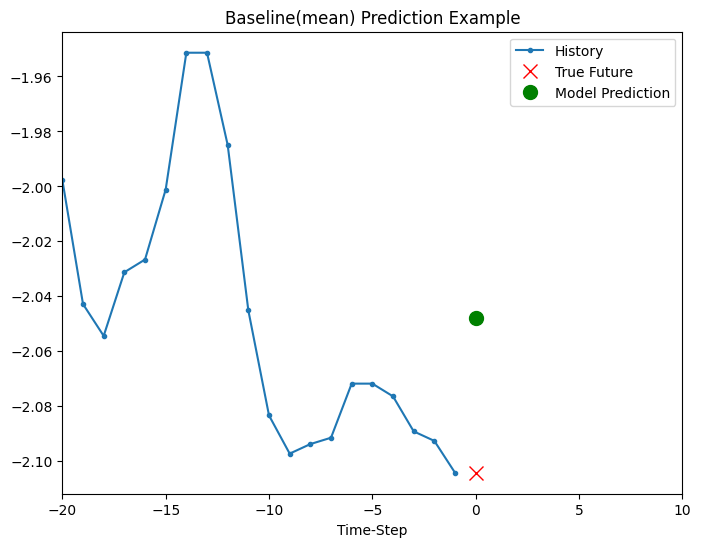

In [56]:
show_plot([x_train_uni[0], y_train_uni[0], baseline(x_train_uni[0])], 0,
           'Baseline(mean) Prediction Example')

In [57]:
BATCH_SIZE = 256
BUFFER_SIZE = 10000

train_univariate = tf.data.Dataset.from_tensor_slices((x_train_uni, y_train_uni))
train_univariate = train_univariate.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_univariate = tf.data.Dataset.from_tensor_slices((x_val_uni, y_val_uni))
val_univariate = val_univariate.batch(BATCH_SIZE).repeat()

In [58]:
train_univariate

<_RepeatDataset element_spec=(TensorSpec(shape=(None, 20, 1), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>

In [60]:
tf.keras.backend.clear_session()

simple_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer((x_train_uni.shape[-2:])),
    #tf.keras.layers.LSTM(8, input_shape=x_train_uni.shape[-2:]),
    tf.keras.layers.LSTM(8),
    tf.keras.layers.Dense(1)
])

simple_lstm_model.compile(optimizer='adam', loss='mae')
simple_lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
for x, y in val_univariate.take(1):
    print(simple_lstm_model.predict(x).shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step  
(256, 1)


In [62]:
EVALUATION_INTERVAL = 200
EPOCHS = 20

history = simple_lstm_model.fit(train_univariate, epochs=EPOCHS,
                      steps_per_epoch=EVALUATION_INTERVAL,
                      validation_data=val_univariate, validation_steps=50)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.5079 - val_loss: 0.0561
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0795 - val_loss: 0.0290
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0406 - val_loss: 0.0214
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0367 - val_loss: 0.0182
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0203 - val_loss: 0.0172
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0216 - val_loss: 0.0174
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0237 - val_loss: 0.0156
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0223 - val_loss: 0.0151
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0207 - val_loss: 0.0148
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0199 - val_loss: 0.0142
Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0157 - val_loss: 0.0140
Epoch 12/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


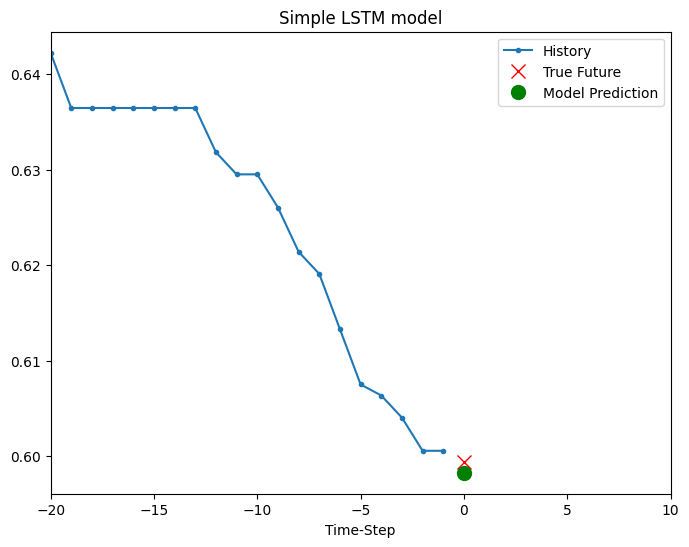

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


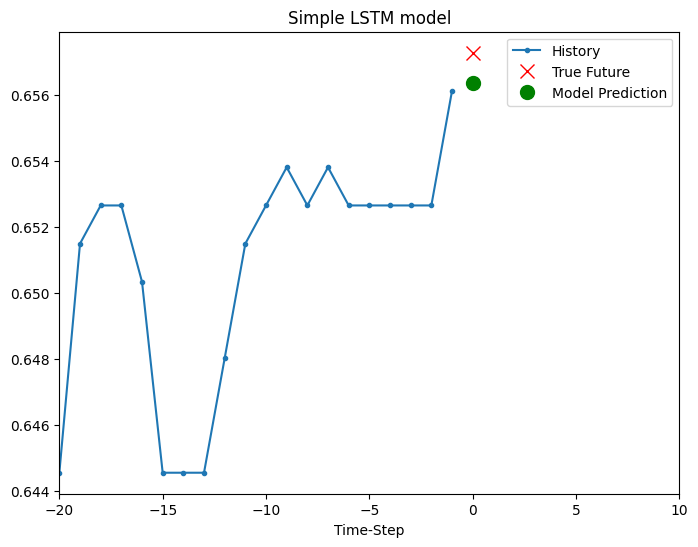

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


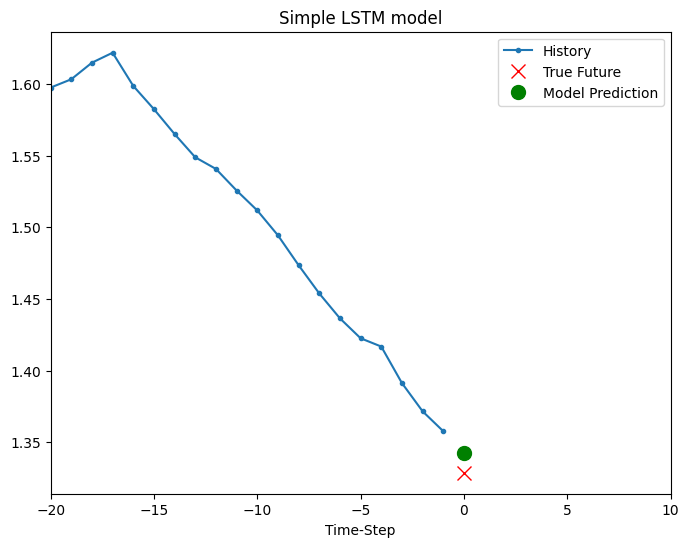

In [71]:
for x, y in val_univariate.take(3):
  plot = show_plot([x[0].numpy(), y[0].numpy(),
                    simple_lstm_model.predict(x)[0]], 0, 'Simple LSTM model')

In [73]:
features_considered = ['p (mbar)', 'T (degC)', 'rho (g/m**3)']
features = df[features_considered]
features.index = df['Date Time']
features

,p (mbar),T (degC),rho (g/m**3)
Date Time,,,
01.01.2009 00:10:00,996.52,-8.02,1307.75
01.01.2009 00:20:00,996.57,-8.41,1309.80
01.01.2009 00:30:00,996.53,-8.51,1310.24
01.01.2009 00:40:00,996.51,-8.31,1309.19
01.01.2009 00:50:00,996.51,-8.27,1309.00
...,...,...,...
31.12.2016 23:20:00,1000.07,-4.05,1292.98
31.12.2016 23:30:00,999.93,-3.35,1289.44
31.12.2016 23:40:00,999.82,-3.16,1288.39


from matplotlib import pyplot as plt
features['p (mbar)'].plot(kind='hist', bins=20, title='p (mbar)')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
features['T (degC)'].plot(kind='hist', bins=20, title='T (degC)')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
features['rho (g/m**3)'].plot(kind='hist', bins=20, title='rho (g/m**3)')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
features.plot(kind='scatter', x='p (mbar)', y='T (degC)', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
features.plot(kind='scatter', x='T (degC)', y='rho (g/m**3)', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
features['p (mbar)'].plot(kind='line', figsize=(8, 4), title='p (mbar)')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
features['T (degC)'].plot(kind='line', figsize=(8, 4), title='T (degC)')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
features['rho (g/m**3)'].plot(kind='line', figsize=(8, 4), title='rho (g/m**3)')
plt.gca().spines[['top', 'right']].set_visible(False)

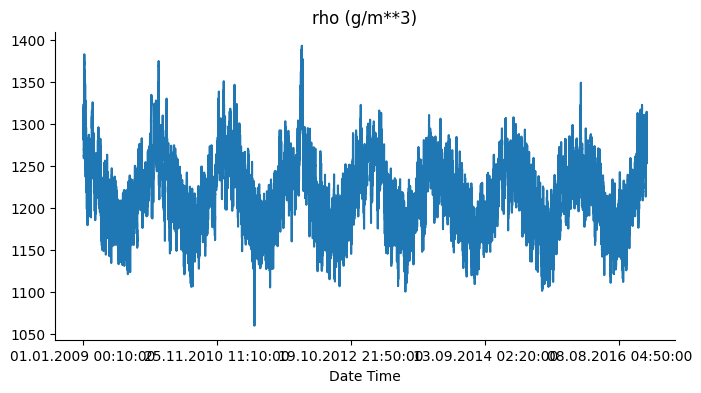

In [77]:
from matplotlib import pyplot as plt
features['rho (g/m**3)'].plot(kind='line', figsize=(8, 4), title='rho (g/m**3)')
plt.gca().spines[['top', 'right']].set_visible(False)

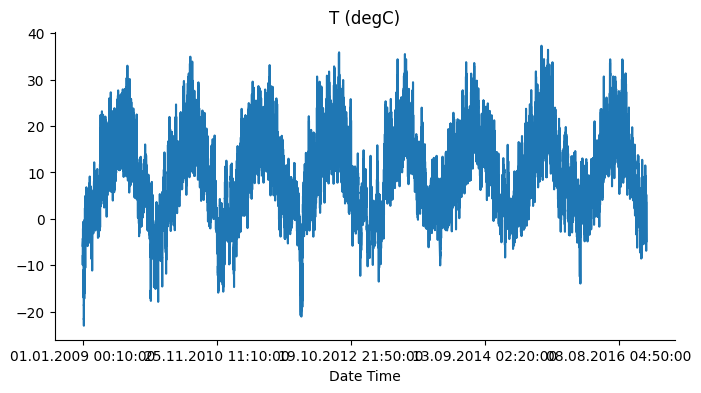

In [76]:
from matplotlib import pyplot as plt
features['T (degC)'].plot(kind='line', figsize=(8, 4), title='T (degC)')
plt.gca().spines[['top', 'right']].set_visible(False)

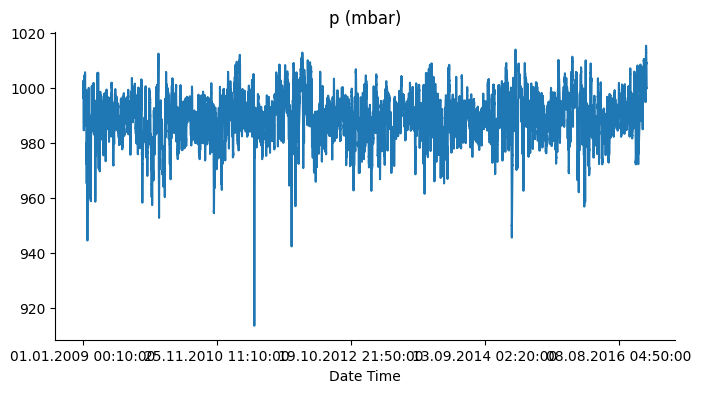

In [75]:
from matplotlib import pyplot as plt
features['p (mbar)'].plot(kind='line', figsize=(8, 4), title='p (mbar)')
plt.gca().spines[['top', 'right']].set_visible(False)

array([<Axes: xlabel='Date Time'>, <Axes: xlabel='Date Time'>,
       <Axes: xlabel='Date Time'>], dtype=object)

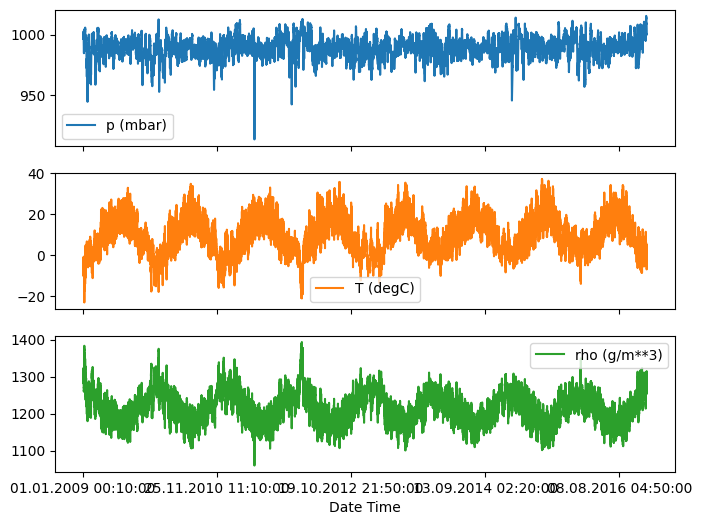

In [74]:
features.plot(subplots=True)

In [78]:
dataset = features.values
data_mean = dataset[:TRAIN_SPLIT].mean(axis=0)
data_std = dataset[:TRAIN_SPLIT].std(axis=0)

In [79]:
data_mean

array([ 988.65117607,    9.2332563 , 1216.40583777])

In [80]:
data_std

array([ 8.23552219,  8.6367204 , 40.86842488])

In [81]:
dataset = (dataset-data_mean)/data_std

In [82]:
dataset.mean()

np.float64(0.028303359322306553)

In [83]:
dataset.std()

np.float64(0.990116848347754)

In [84]:
def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
  data = []
  labels = []

  start_index = start_index + history_size
  if end_index is None:
    end_index = len(dataset) - target_size

  for i in range(start_index, end_index):
    indices = range(i-history_size, i, step)
    data.append(dataset[indices])

    if single_step:
      labels.append(target[i+target_size])
    else:
      labels.append(target[i:i+target_size])

  return np.array(data), np.array(labels)

In [85]:
past_history = 720
future_target = 72
STEP = 6

x_train_single, y_train_single = multivariate_data(dataset, dataset[:, 1], 0,
                                                   TRAIN_SPLIT, past_history,
                                                   future_target, STEP,
                                                   single_step=True)
x_val_single, y_val_single = multivariate_data(dataset, dataset[:, 1],
                                               TRAIN_SPLIT, None, past_history,
                                               future_target, STEP,
                                               single_step=True)

In [86]:
x_train_single.shape

(299280, 120, 3)

In [87]:
print ('Single window of past history : {}'.format(x_train_single[0].shape))

Single window of past history : (120, 3)


In [88]:
train_data_single = tf.data.Dataset.from_tensor_slices((x_train_single, y_train_single))
train_data_single = train_data_single.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data_single = tf.data.Dataset.from_tensor_slices((x_val_single, y_val_single))
val_data_single = val_data_single.batch(BATCH_SIZE).repeat()

In [89]:
train_data_single

<_RepeatDataset element_spec=(TensorSpec(shape=(None, 120, 3), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>

In [91]:
single_step_model = tf.keras.models.Sequential()
single_step_model.add(tf.keras.layers.InputLayer((x_train_single.shape[-2:])))
#single_step_model.add(tf.keras.layers.LSTM(32, input_shape=x_train_single.shape[-2:]))
single_step_model.add(tf.keras.layers.LSTM(32))
single_step_model.add(tf.keras.layers.Dense(1))

single_step_model.compile(optimizer=tf.keras.optimizers.RMSprop(), loss='mae')
single_step_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,641 (18.13 KB)

 Trainable params: 4,641 (18.13 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:
for x, y in val_data_single.take(1):
  print(single_step_model.predict(x).shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
(256, 1)


In [93]:
single_step_history = single_step_model.fit(train_data_single, epochs=EPOCHS,
                                            steps_per_epoch=EVALUATION_INTERVAL,
                                            validation_data=val_data_single,
                                            validation_steps=50)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 93ms/step - loss: 0.3710 - val_loss: 0.2542
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - loss: 0.2697 - val_loss: 0.2364
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - loss: 0.2657 - val_loss: 0.2488
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 103ms/step - loss: 0.2624 - val_loss: 0.2328
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - loss: 0.2187 - val_loss: 0.2282
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - loss: 0.2411 - val_loss: 0.2490
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - loss: 0.2391 - val_loss: 0.2554
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - loss: 0.2404 - val_loss: 0.2480
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - loss: 0.2442 - val_loss: 0.2397
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - loss: 0.2534 - val_loss: 0.2337
Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - loss: 0.2127 - val_loss: 0.2361
Epoch 12/20
200/200 ━━

In [94]:
def plot_train_history(history, title):
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  epochs = range(len(loss))
  plt.figure()
  plt.plot(epochs, loss, 'b', label='Training loss')
  plt.plot(epochs, val_loss, 'r', label='Validation loss')
  plt.title(title)
  plt.legend()
  plt.show()

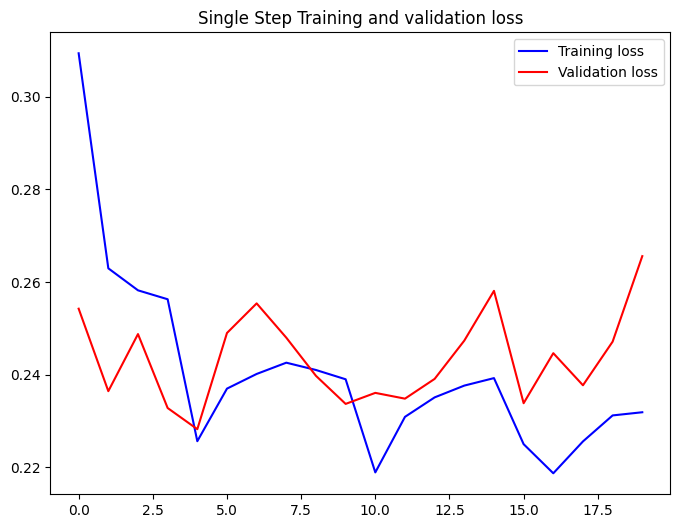

In [95]:
plot_train_history(single_step_history,
                   'Single Step Training and validation loss')

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


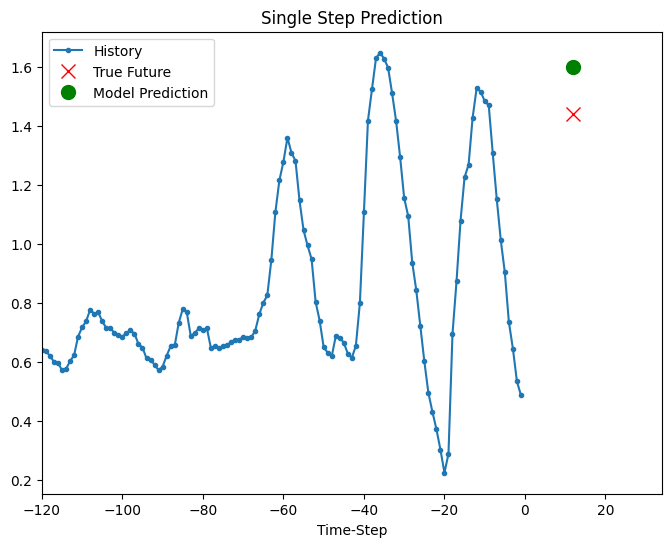

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


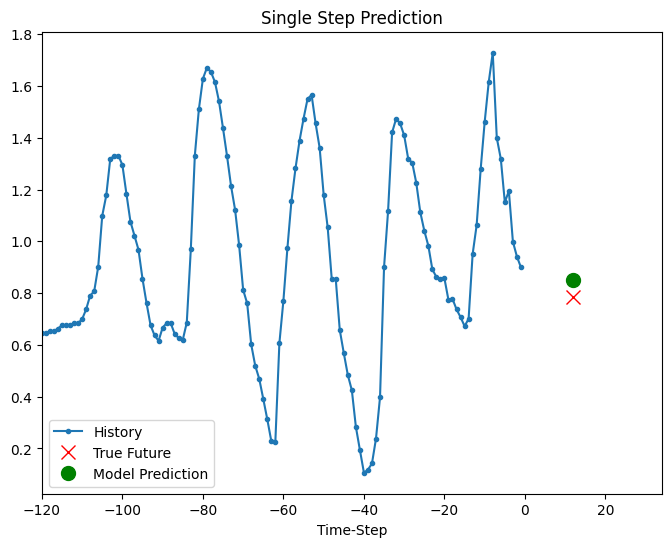

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


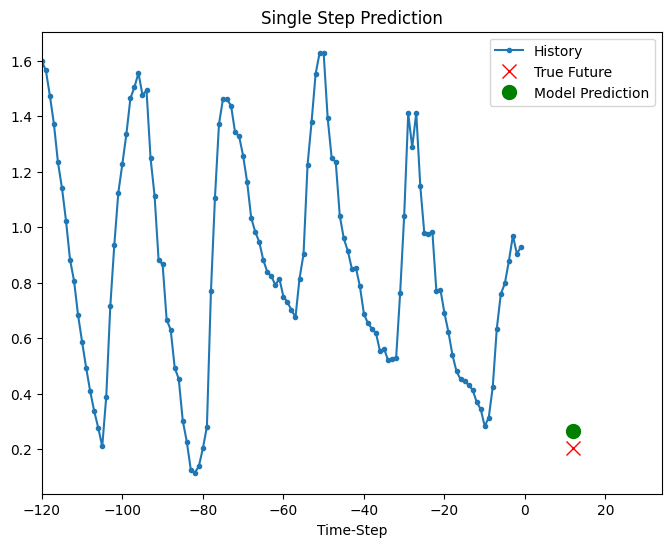

In [97]:
for x, y in val_data_single.take(3):
  plot = show_plot([x[0][:, 1].numpy(), y[0].numpy(),
                    single_step_model.predict(x)[0]], 12,
                   'Single Step Prediction')

In [98]:
future_target = 72
x_train_multi, y_train_multi = multivariate_data(dataset, dataset[:, 1], 0,
                                                 TRAIN_SPLIT, past_history,
                                                 future_target, STEP)
x_val_multi, y_val_multi = multivariate_data(dataset, dataset[:, 1],
                                             TRAIN_SPLIT, None, past_history,
                                             future_target, STEP)

In [100]:
x_train_multi.shape

(299280, 120, 3)

In [103]:
y_train_multi.shape

(299280, 72)

In [102]:
print ('Single window of past history : {}'.format(x_train_multi[0].shape))
print ('Target temperature to predict : {}'.format(y_train_multi[0].shape))

Single window of past history : (120, 3)
Target temperature to predict : (72,)


In [104]:
train_data_multi = tf.data.Dataset.from_tensor_slices((x_train_multi, y_train_multi))
train_data_multi = train_data_multi.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_data_multi = tf.data.Dataset.from_tensor_slices((x_val_multi, y_val_multi))
val_data_multi = val_data_multi.batch(BATCH_SIZE).repeat()

In [105]:
train_data_multi

<_RepeatDataset element_spec=(TensorSpec(shape=(None, 120, 3), dtype=tf.float64, name=None), TensorSpec(shape=(None, 72), dtype=tf.float64, name=None))>

In [106]:
def multi_step_plot(history, true_future, prediction):
  plt.figure(figsize=(12, 6))
  num_in = create_time_steps(len(history))
  num_out = len(true_future)

  plt.plot(num_in, np.array(history[:, 1]), label='History')
  plt.plot(np.arange(num_out)/STEP, np.array(true_future), 'bo',
           label='True Future')
  if prediction.any():
    plt.plot(np.arange(num_out)/STEP, np.array(prediction), 'ro',
             label='Predicted Future')
  plt.legend(loc='upper left')
  plt.show()

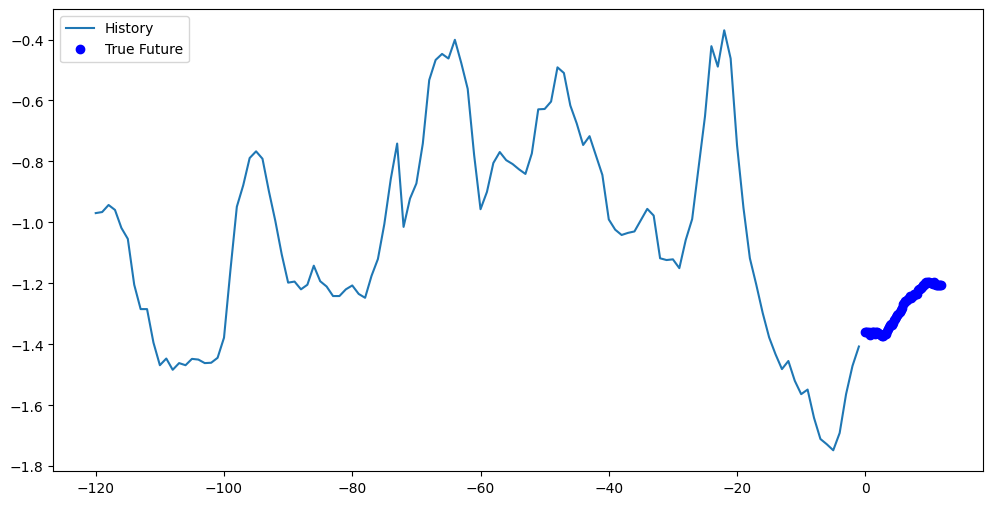

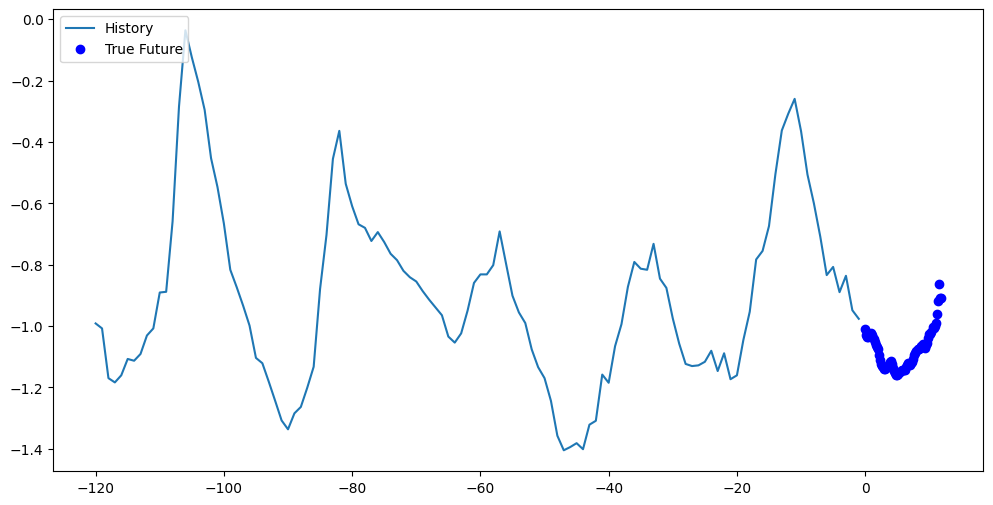

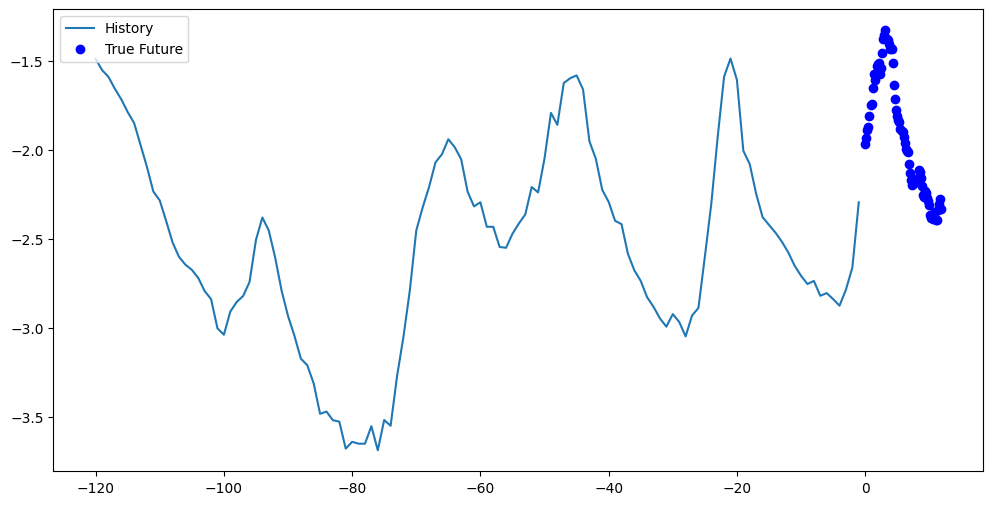

In [133]:
for x, y in train_data_multi.take(3):
  multi_step_plot(x[0], y[0], np.array([0]))

In [109]:
multi_step_model = tf.keras.models.Sequential()
multi_step_model.add(tf.keras.layers.InputLayer((x_train_multi.shape[-2:])))
multi_step_model.add(tf.keras.layers.LSTM(32, return_sequences=True))
#multi_step_model.add(tf.keras.layers.LSTM(32, return_sequences=True, input_shape=x_train_multi.shape[-2:]))
multi_step_model.add(tf.keras.layers.LSTM(16, activation='relu'))
multi_step_model.add(tf.keras.layers.Dense(72))

multi_step_model.compile(optimizer=tf.keras.optimizers.RMSprop(clipvalue=1.0), loss='mae')

In [110]:
for x, y in val_data_multi.take(1):
  print (multi_step_model.predict(x).shape)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
(256, 72)


In [111]:
multi_step_history = multi_step_model.fit(train_data_multi, epochs=EPOCHS,
                                          steps_per_epoch=EVALUATION_INTERVAL,
                                          validation_data=val_data_multi,
                                          validation_steps=50)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 37s 160ms/step - loss: 0.6478 - val_loss: 0.2924
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 30s 152ms/step - loss: 0.3348 - val_loss: 0.2766
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 42s 209ms/step - loss: 0.3344 - val_loss: 0.2438
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 40s 201ms/step - loss: 3.9662 - val_loss: 39.6928
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 205ms/step - loss: 79.8498 - val_loss: 0.2282
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 32s 161ms/step - loss: 0.2322 - val_loss: 0.2331
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 156ms/step - loss: 0.2219 - val_loss: 0.2069
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 207ms/step - loss: 0.2072 - val_loss: 0.2058
Epoch 9/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 154ms/step - loss: 0.2102 - val_loss: 0.1968
Epoch 10/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 205ms/step - loss: 0.2045 - val_loss: 0.1927
Epoch 11/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 207ms/step - loss: 0.1710 - val_loss: 0.1840
Epoch 12/20
200/2

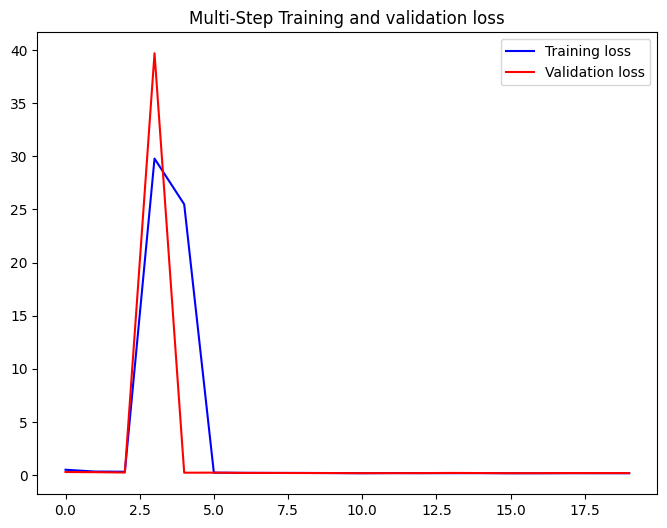

In [112]:
plot_train_history(multi_step_history, 'Multi-Step Training and validation loss')

In [130]:
for x, y in val_data_multi.take(3):
  print(x.shape,y.shape)
  print(x[0].shape,y[0].shape)
  print(x[0,0], y[0,0])

(256, 120, 3) (256, 72)
(120, 3) (72,)
tf.Tensor([ 0.54748489  0.642228   -0.54922199], shape=(3,), dtype=float64) tf.Tensor(0.3689761336626933, shape=(), dtype=float64)
(256, 120, 3) (256, 72)
(120, 3) (72,)
tf.Tensor([ 0.48798653  0.6445437  -0.56439263], shape=(3,), dtype=float64) tf.Tensor(0.8645346098828947, shape=(), dtype=float64)
(256, 120, 3) (256, 72)
(120, 3) (72,)
tf.Tensor([ 0.14435319  1.5974517  -1.44820452], shape=(3,), dtype=float64) tf.Tensor(0.6850683392891302, shape=(), dtype=float64)


In [132]:
y_hat=multi_step_model.predict(x)
print(y_hat.shape)
print(y_hat[0].shape)
print(y_hat[0,0])

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
(256, 72)
(72,)
0.91380167


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


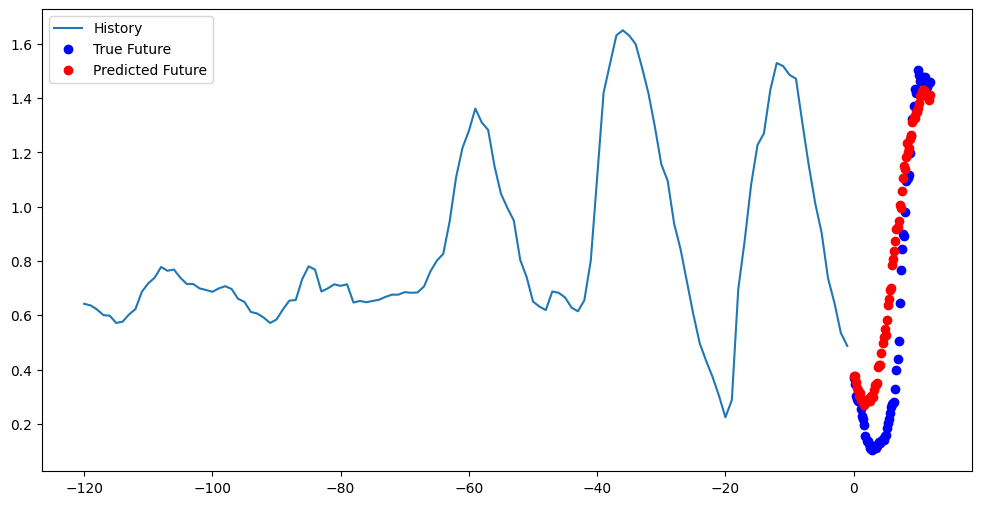

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


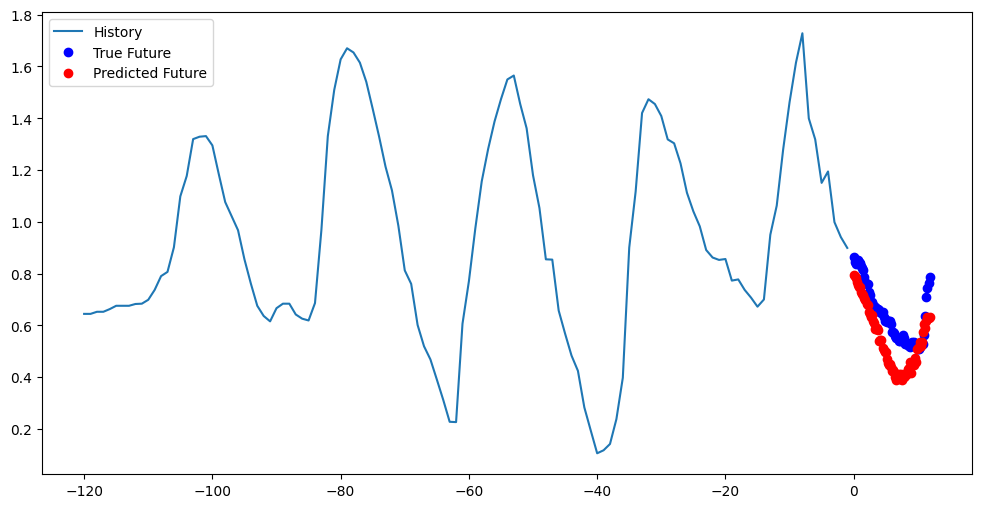

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


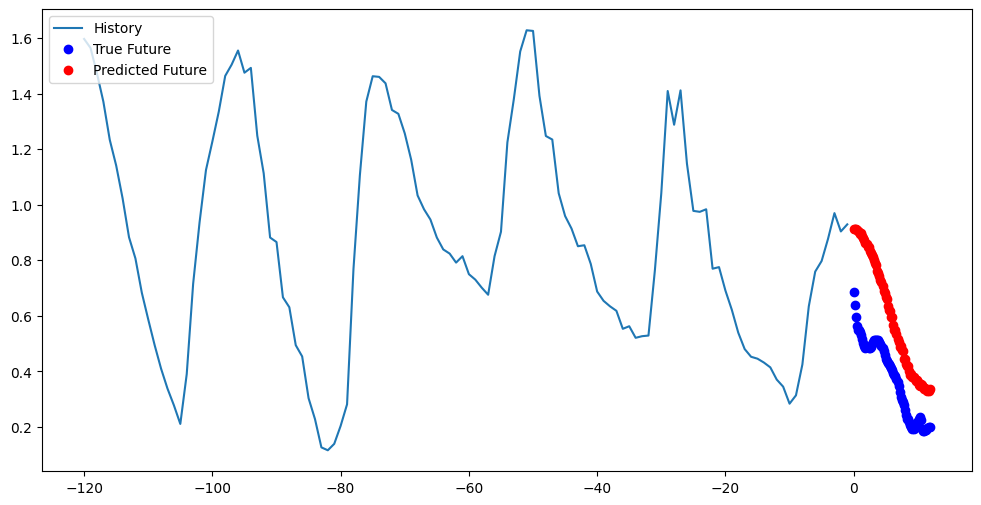

In [126]:
for x, y in val_data_multi.take(3):
  multi_step_plot(x[0], y[0], multi_step_model.predict(x)[0])